# Mobile Money In Africa

In [2]:
# Importing all required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
Registered_Accounts = pd.read_csv("../Datasets/Registered_Accounts.csv")
Registered_Accounts.head()

,Date,Clean Date,Northern Africa,Eastern Africa,Southern Africa,Western Africa,Sub-Saharan Africa
0,Dec-11,12/01/11,49656.0,39836904.0,463200,6768709.0,47324930
1,Mar-12,03/01/12,53076.0,44189814.0,541375,8536718.0,53647306
2,Jun-12,06/01/12,89938.0,49229726.0,625960,9792990.0,60332950
3,Sep-12,09/01/12,137413.0,51953008.0,861099,10172703.0,64712998
4,Dec-12,12/01/12,200723.0,56991820.0,1222403,12499816.0,73399764


In [5]:
#Converting all columns names to lowercase
Registered_Accounts.columns = Registered_Accounts.columns.str.lower()

# Remove leading/trailing spaces and replace internal spaces with underscores
Registered_Accounts.columns = Registered_Accounts.columns.str.strip().str.replace(' ', '_')

print(Registered_Accounts.columns.tolist())

['date', 'clean_date', 'northern_africa', 'eastern_africa', 'southern_africa', 'western_africa', 'sub-saharan_africa']


In [6]:
Registered_Accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                53 non-null     object 
 1   clean_date          53 non-null     object 
 2   northern_africa     53 non-null     float64
 3   eastern_africa      53 non-null     float64
 4   southern_africa     53 non-null     int64  
 5   western_africa      53 non-null     float64
 6   sub-saharan_africa  53 non-null     int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 3.0+ KB


In [7]:
Registered_Accounts["clean_date"] = pd.to_datetime(Registered_Accounts["clean_date"])

/tmp/ipykernel_14318/3784108915.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Registered_Accounts["clean_date"] = pd.to_datetime(Registered_Accounts["clean_date"])


In [8]:
Registered_Accounts["clean_date"].head()
# Registered_Accounts["date"].dtype

0   2011-12-01
1   2012-03-01
2   2012-06-01
3   2012-09-01
4   2012-12-01
Name: clean_date, dtype: datetime64[ns]

In [9]:
Registered_Accounts.isnull().sum()

date                  0
clean_date            0
northern_africa       0
eastern_africa        0
southern_africa       0
western_africa        0
sub-saharan_africa    0
dtype: int64

In [16]:
Registered_Accounts.describe()

,clean_date,northern_africa,eastern_africa,southern_africa,western_africa,sub-saharan_africa
count,53,5.300000e+01,5.300000e+01,5.300000e+01,5.300000e+01,5.300000e+01
mean,2018-06-01 05:53:12.452830208,9.562183e+06,2.159904e+08,1.070917e+07,1.572363e+08,4.226528e+08
min,2011-12-01 00:00:00,4.965600e+04,3.983690e+07,4.632000e+05,6.768709e+06,4.732493e+07
25%,2015-03-01 00:00:00,2.453606e+06,1.088034e+08,6.235602e+06,4.120204e+07,1.747058e+08
50%,2018-06-01 00:00:00,9.482096e+06,2.142979e+08,9.246501e+06,1.319636e+08,3.948585e+08
75%,2021-09-01 00:00:00,1.511401e+07,2.936892e+08,1.532694e+07,2.287225e+08,5.942849e+08
max,2024-12-01 00:00:00,2.547850e+07,4.587919e+08,2.717024e+07,4.845307e+08,1.074562e+09
std,NaN,7.284659e+06,1.169048e+08,7.082397e+06,1.339805e+08,2.834977e+08


In [10]:
Registered_Accounts.describe().T

,count,mean,min,25%,50%,75%,max,std
clean_date,53,2018-06-01 05:53:12.452830208,2011-12-01 00:00:00,2015-03-01 00:00:00,2018-06-01 00:00:00,2021-09-01 00:00:00,2024-12-01 00:00:00,NaN
northern_africa,53.0,9562183.245283,49656.0,2453606.0,9482096.0,15114010.0,25478497.0,7284658.95503
eastern_africa,53.0,215990367.360377,39836904.0,108803351.0,214297892.0,293689222.0,458791889.0,116904822.368339
southern_africa,53.0,10709167.075472,463200.0,6235602.0,9246501.0,15326938.0,27170235.0,7082396.915803
western_africa,53.0,157236296.273585,6768709.0,41202038.0,131963615.0,228722492.0,484530669.0,133980468.544369
sub-saharan_africa,53.0,422652756.641509,47324930.0,174705768.0,394858524.0,594284890.0,1074562313.0,283497661.570554


### Exploratory Data Analysis for Registered Accounts

In [ ]:
#Filtering the data to select months == 12(Dec) and creating an independent dataset based on that for the analysis
Registered_Acc_Dec_raw = Registered_Accounts[
    Registered_Accounts["clean_date"].dt.month == 12
].copy()

In [12]:
#Filtering the data
# Extracting the year from the clean date column
# (Errors='coerce' handles any messy strings safely)
Registered_Acc_Dec_raw["Year"] = pd.to_datetime(Registered_Acc_Dec_raw["clean_date"]).dt.year

In [13]:
# Reshaping the data
Registered_Acc_Dec = Registered_Acc_Dec_raw.melt(
    id_vars=["date", "clean_date"], # date and clean_date are preserved for each row and stays as it is
    value_vars=[    # Collapsing them into rows
        "northern_africa",
        "eastern_africa",
        "southern_africa",
        "western_africa",
        "sub-saharan_africa"
    ],
    var_name="Region",
    value_name="Value"
)

In [14]:
Registered_Acc_Dec.head()

,date,clean_date,Region,Value
0,Dec-11,2011-12-01,northern_africa,49656.0
1,Dec-12,2012-12-01,northern_africa,200723.0
2,Dec-13,2013-12-01,northern_africa,751120.2
3,Dec-14,2014-12-01,northern_africa,1954140.0
4,Dec-15,2015-12-01,northern_africa,5031929.0


In [15]:
Registered_Acc_Dec["Value"] = pd.to_numeric(Registered_Acc_Dec["Value"])

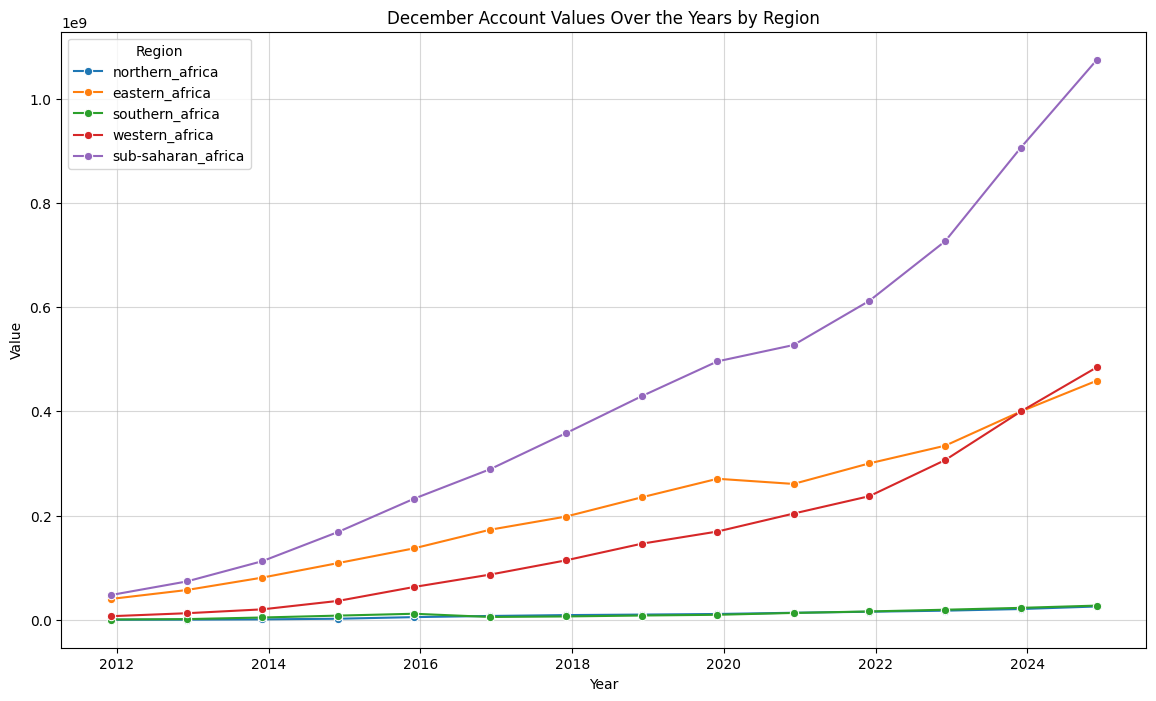

In [ ]:
# 3. Plot using "date" on the X-axis
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=Registered_Acc_Dec,
    x="clean_date",          # Using 'date' directly since it represents the years
    y="Value",
    hue="Region",
    marker="o"
)

plt.title("December Account Values Over the Years by Region")
plt.xlabel("Year")
plt.ylabel("Value")
plt.grid(True, linestyle="-", alpha=0.5)

plt.savefig("/home/yaa_baby/Documents/PROJECTS/Momo_In_Africa/Save_Plots/Registered_Acc.png")

plt.show()